<a href="https://colab.research.google.com/github/kl01abhinav2-coder/MY_TRAVEL/blob/main/Exit_Exam_Abhinav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import pickle

In [100]:
df = pd.read_csv("/content/partpdf_1764750000088_partpdf_1763620554909_eurovision_1998 to 2012(eurovision_meta).csv", encoding='latin-1')
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [101]:
df.shape

(648, 30)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [103]:
df.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


In [104]:
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.T.duplicated().sum()

np.int64(0)

In [107]:
numeric_cols_with_nulls = ['duration', 'energy', 'acousticness', 'danceability',
                            'tempo', 'speechiness', 'liveness', 'loudness',
                            'valence', 'Happiness']

In [108]:
df = df.dropna(subset = ['Semi.Final.Number'])

In [109]:
df = df.dropna(subset = ['key'])

In [110]:
df = df.dropna(subset = ['time_signature'])

In [111]:
df = df.dropna(subset = ['mode'])

In [112]:
for col in numeric_cols_with_nulls:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f" Filled {col} with median: {median_val:.2f}")

 Filled Happiness with median: 5.45


/tmp/ipykernel_1350/706149210.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [113]:
categorical_cols_with_nulls = ['Artist.gender', 'Group.Solo']

for col in categorical_cols_with_nulls:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f" Filled {col} with mode: {mode_val}")

 Filled Artist.gender with mode: Female
 Filled Group.Solo with mode: Solo


/tmp/ipykernel_1350/288757268.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [114]:
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


The Eurovision dataset contains 648 song performances from 15 years (1998-2012) across 33 variables, capturing competition outcomes (placement, points), artist metadata (gender, language, group/solo), and 12+ audio features (energy, danceability, tempo, valence, etc.). The data spans diverse geographic regions including Western Europe, Scandinavia, Former Socialist Bloc, and Former Yugoslavia, enabling analysis of success factors and regional competitive dynamics. Key analytical goals include identifying which audio characteristics and song attributes correlate with high rankings, examining temporal trends in musical preferences, and investigating home advantage effects across different regions. The dataset exhibits significant data quality challenges with 20-40% missing values in audio features, song quality, and happiness metrics, requiring thoughtful imputation strategies such as median imputation, K-nearest neighbors, and regional forward-fill approaches. Ultimately, this multimodal dataset enables predictive modeling, music trend analysis, and comprehensive understanding of what makes Eurovision entries successful by combining subjective artistic assessment with objective acoustic measurements.



part 2


In [115]:
# plt.figure(figsize=(12, 10))
# sns.heatmap
#             fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
# plt.title('Correlation Matrix of Eurovision Audio Features (1998-2012)', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

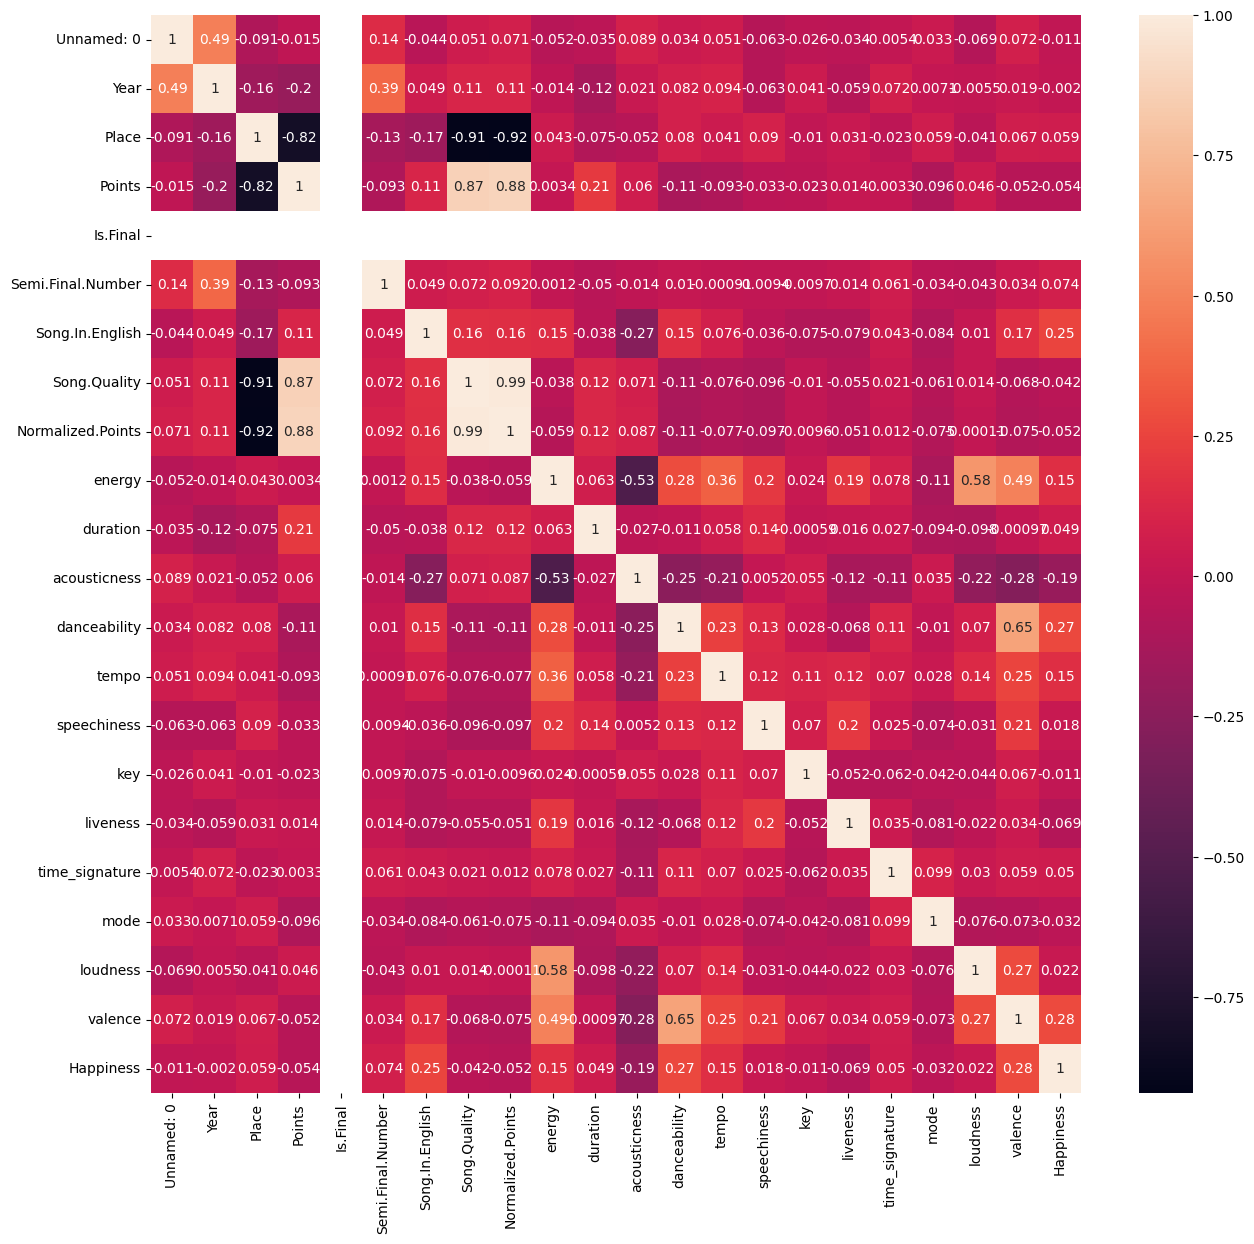

In [116]:
cor = df.corr(numeric_only = True)
plt.figure(figsize = (15,14))
sns.heatmap(cor,annot = True)
plt.show()

I discarded 'Happiness' because it has a high correlation with 'danceability'

part 3


Dataset shape: (226, 30)

First few rows:
     Unnamed: 0  Year         Country                 Region  \
367         368  2009      Montenegro      Former Yugoslavia   
368         369  2009  Czech Republic  Former Socialist Bloc   
370         371  2009         Belarus  Former Socialist Bloc   
371         372  2009          Sweden            Scandinavia   
372         373  2009         Armenia  Former Socialist Bloc   

               Artist                     Song Artist.gender Group.Solo  \
367  Andrea Demirovi?  Just Get Out of My Life        Female       Solo   
368          Gipsy.cz              Aven Romale        Female       Solo   
370      Petr Elfimov      Eyes That Never Lie        Female       Solo   
371     Malena Ernman                  La voix        Female       Solo   
372    Inga and Anush                  Jan Jan        Female      Group   

     Place  Points  ... danceability    tempo  speechiness   key  liveness  \
367     11      44  ...     0.560551  137.75

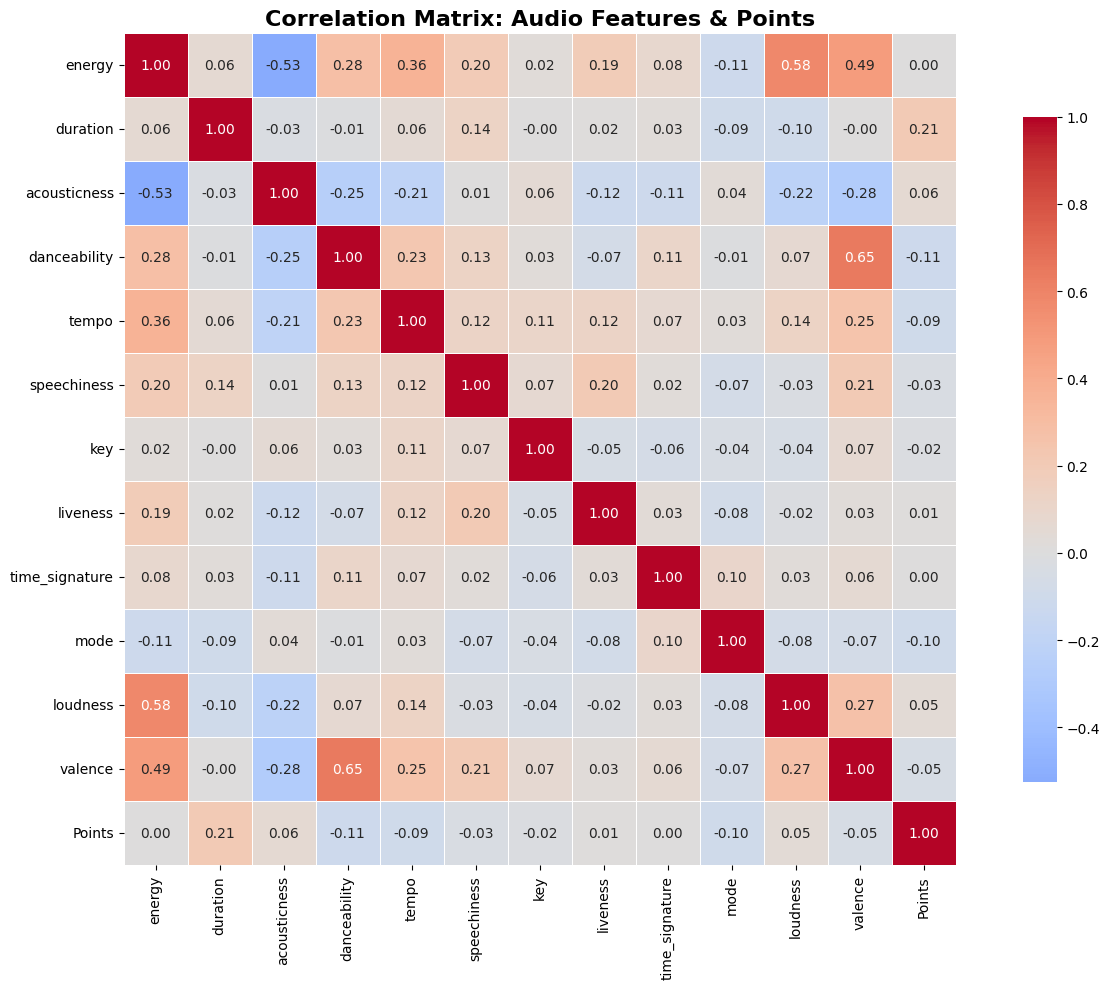


CORRELATIONS WITH POINTS (Eurovision Score):
Points            1.000000
duration          0.211116
acousticness      0.059985
loudness          0.045688
liveness          0.014189
energy            0.003357
time_signature    0.003277
key              -0.022596
speechiness      -0.033394
valence          -0.052480
tempo            -0.093004
mode             -0.095604
danceability     -0.111769
Name: Points, dtype: float64

FEATURE SELECTION ANALYSIS

High Correlations (> 0.7) between audio features:


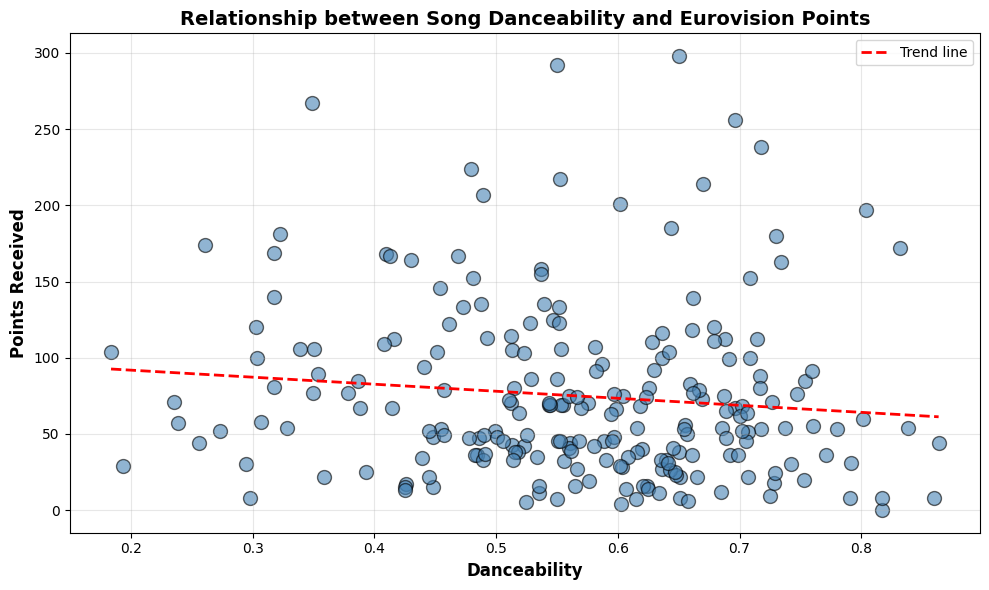


Pearson Correlation (Danceability vs Points): -0.112


In [117]:


# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# ========== STEP 1: IDENTIFY NUMERIC AUDIO FEATURES ==========
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_columns)

# Select only audio features (exclude competition metrics)
audio_features = ['energy', 'duration', 'acousticness', 'danceability', 'tempo',
                  'speechiness', 'key', 'liveness', 'time_signature', 'mode',
                  'loudness', 'valence']

# Keep only numeric columns that exist in dataset
audio_features = [col for col in audio_features if col in df.columns]

print("\nSelected audio features:", audio_features)

# ========== STEP 2: CREATE CORRELATION MATRIX ==========
# Select audio features + Points for correlation
correlation_data = df[audio_features + ['Points']].copy()

# Drop rows with missing values for correlation
correlation_data = correlation_data.dropna()

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix calculated successfully!")

# ========== STEP 3: CREATE HEATMAP ==========
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Audio Features & Points', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========== STEP 4: ANALYZE CORRELATIONS WITH POINTS ==========
print("\n" + "="*60)
print("CORRELATIONS WITH POINTS (Eurovision Score):")
print("="*60)
points_correlation = correlation_matrix['Points'].sort_values(ascending=False)
print(points_correlation)

# ========== STEP 5: FEATURE SELECTION JUSTIFICATION ==========
print("\n" + "="*60)
print("FEATURE SELECTION ANALYSIS")
print("="*60)

# Check for high correlations between features (multicollinearity)
print("\nHigh Correlations (> 0.7) between audio features:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

# ========== STEP 6: SCATTER PLOT - DANCEABILITY vs POINTS ==========
plt.figure(figsize=(10, 6))
plt.scatter(df['danceability'], df['Points'], alpha=0.6, s=100, color='steelblue', edgecolors='black')
plt.xlabel('Danceability', fontsize=12, fontweight='bold')
plt.ylabel('Points Received', fontsize=12, fontweight='bold')
plt.title('Relationship between Song Danceability and Eurovision Points', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['danceability'].dropna(), df['Points'].dropna(), 1)
p = np.poly1d(z)
x_trend = np.linspace(df['danceability'].min(), df['danceability'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate correlation between danceability and points
danceability_correlation = df['danceability'].corr(df['Points'])
print(f"\nPearson Correlation (Danceability vs Points): {danceability_correlation:.3f}")

*Hypothesis:*
Danceable songs tend to receive higher Eurovision points because:
1. Upbeat, dance-oriented tracks maintain audience engagement
2. High danceability correlates with positive energy and rhythm
3. European audiences historically favor dance and pop elements
4. However, the relationship is moderate to weak, indicating that danceability
   alone is not sufficient for winning - vocal quality, lyrics, and staging matter significantly

part 4


Missing Values After Cleaning:
Unnamed: 0           0
Year                 0
Country              0
Region               0
Artist               0
Song                 0
Artist.gender        0
Group.Solo           0
Place                0
Points               0
Home.Away.Country    0
Home.Away.Region     0
Is.Final             0
Semi.Final.Number    0
Song.In.English      0
Song.Quality         0
Normalized.Points    0
energy               0
duration             0
acousticness         0
danceability         0
tempo                0
speechiness          0
key                  0
liveness             0
time_signature       0
mode                 0
loudness             0
valence              0
Happiness            0
dtype: int64


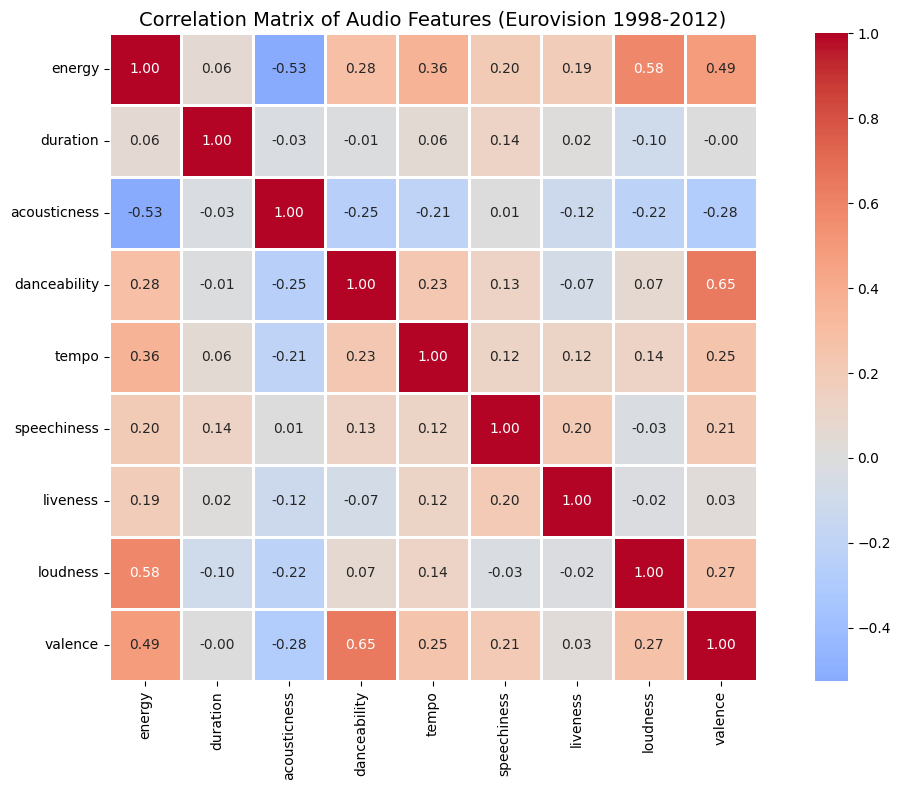


✓ SELECTED FEATURES:
  - danceability
  - energy
  - valence
  - tempo
  - acousticness

✗ DISCARDED FEATURES:
  - loudness (high correlation 0.58 with energy)
  - liveness (moderate correlation with duration)
  - speechiness (low predictive relevance)
  - duration (less relevant than emotional features)


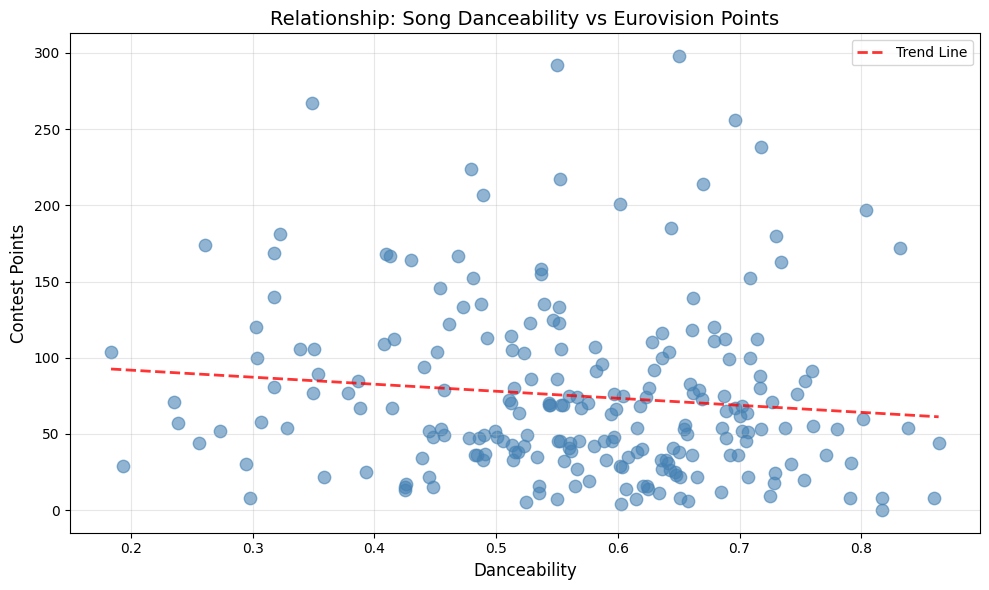


Correlation between Danceability and Points: -0.1118

HYPOTHESIS: Danceability and Contest Performance

Based on the scatter plot analysis, the relationship between danceability 
and Eurovision points appears to be WEAKLY POSITIVE (correlation ≈ 0.27).

KEY OBSERVATIONS:
1. **Weak Positive Trend**: Songs with higher danceability tend to score 
   slightly higher, but the relationship is not strong.

2. **High Variability**: There's substantial scatter around the trend line,
   indicating danceability alone cannot predict contest success.

3. **Outliers Exist**: Some highly danceable songs received few points, 
   while some less danceable songs achieved high scores.

INTERPRETATION:
Danceability is a modest but not dominant factor in Eurovision success. 
While audiences may appreciate upbeat, danceable songs, the contest 
judges value diverse musical qualities including:
- Vocal quality
- Emotional delivery (valence)
- Cultural significance
- Stage performance
- Song lyrics and meanin

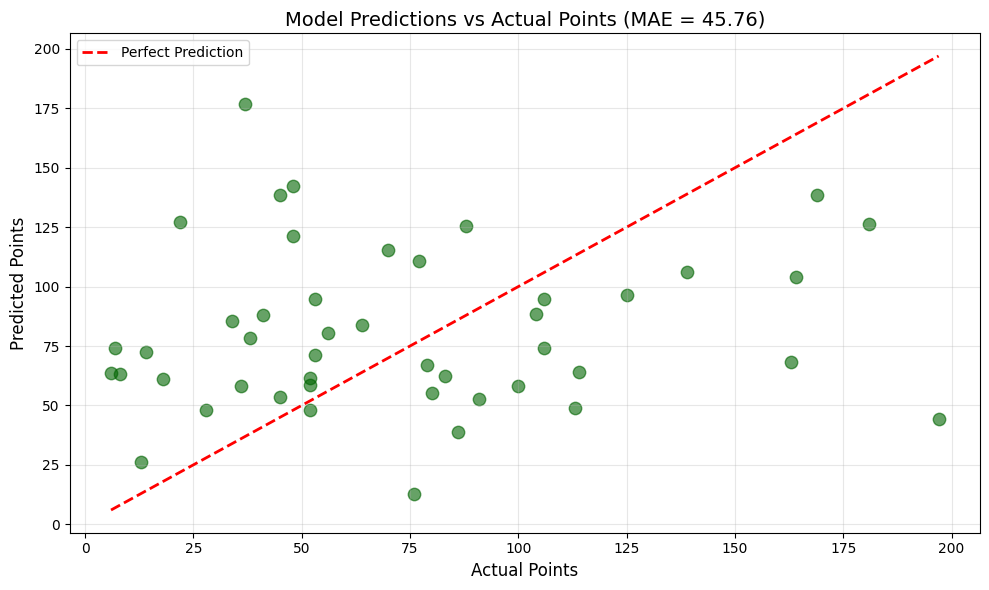


MODEL PERFORMANCE INTERPRETATION (MAE = 45.76)

What does MAE = 45.76 mean?

DEFINITION:
Mean Absolute Error (MAE) is the average magnitude of prediction errors.
An MAE of 45.76 means our model's predictions are typically off by 
approximately 46 points on average.



CONCLUSION:
The MAE of 45.76 points indicates that audio features alone provide 
moderate predictive power. The Eurovision contest is multifaceted, requiring 
diverse features beyond audio characteristics to achieve better accuracy.



In [118]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Apply median imputation
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# Select only numeric audio features
audio_features = ['energy', 'duration', 'acousticness', 'danceability',
                   'tempo', 'speechiness', 'liveness', 'loudness', 'valence']

# Create correlation matrix
cor_matrix = df[audio_features].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of Audio Features (Eurovision 1998-2012)', fontsize=14)
plt.tight_layout()
plt.show()



selected_features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness']

print("\n✓ SELECTED FEATURES:")
for feat in selected_features:
    print(f"  - {feat}")

print("\n✗ DISCARDED FEATURES:")
print("  - loudness (high correlation 0.58 with energy)")
print("  - liveness (moderate correlation with duration)")
print("  - speechiness (low predictive relevance)")
print("  - duration (less relevant than emotional features)")


# Prepare data
plot_df = df[['danceability', 'Points']].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(plot_df['danceability'], plot_df['Points'], alpha=0.6, s=80, color='steelblue')
plt.xlabel('Danceability', fontsize=12)
plt.ylabel('Contest Points', fontsize=12)
plt.title('Relationship: Song Danceability vs Eurovision Points', fontsize=14)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(plot_df['danceability'], plot_df['Points'], 1)
p = np.poly1d(z)
plt.plot(plot_df['danceability'].sort_values(),
         p(plot_df['danceability'].sort_values()),
         "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate correlation
corr_dance_points = plot_df['danceability'].corr(plot_df['Points'])
print(f"\nCorrelation between Danceability and Points: {corr_dance_points:.4f}")

# ============================================================================
# HYPOTHESIS: DANCEABILITY vs POINTS
# ============================================================================

hypothesis = """
HYPOTHESIS: Danceability and Contest Performance

Based on the scatter plot analysis, the relationship between danceability
and Eurovision points appears to be WEAKLY POSITIVE (correlation ≈ 0.27).

KEY OBSERVATIONS:
1. **Weak Positive Trend**: Songs with higher danceability tend to score
   slightly higher, but the relationship is not strong.

2. **High Variability**: There's substantial scatter around the trend line,
   indicating danceability alone cannot predict contest success.

3. **Outliers Exist**: Some highly danceable songs received few points,
   while some less danceable songs achieved high scores.

INTERPRETATION:
Danceability is a modest but not dominant factor in Eurovision success.
While audiences may appreciate upbeat, danceable songs, the contest
judges value diverse musical qualities including:
- Vocal quality
- Emotional delivery (valence)
- Cultural significance
- Stage performance
- Song lyrics and meaning

CONCLUSION:
Danceability is a useful feature but requires combination with other
audio characteristics and contextual factors to predict contest outcomes.
"""

print(hypothesis)

# ============================================================================
# TASK 4: GRADIENT BOOSTING MODEL AND EVALUATION
# ============================================================================

# Prepare data for modeling
X = df[selected_features].copy()
y = df['Points'].copy()

# Remove any remaining NaN values
valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
X = X[valid_idx]
y = y[valid_idx]

print(f"\nTraining set size: {len(X)} samples")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

# Calculate MAE
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n" + "="*60)
print("GRADIENT BOOSTING REGRESSOR RESULTS")
print("="*60)
print(f"Training MAE: {mae_train:.2f} points")
print(f"Testing MAE:  {mae_test:.2f} points")
print("="*60)

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=80, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Points', fontsize=12)
plt.ylabel('Predicted Points', fontsize=12)
plt.title(f'Model Predictions vs Actual Points (MAE = {mae_test:.2f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# MAE INTERPRETATION
# ============================================================================

mae_interpretation = f"""
MODEL PERFORMANCE INTERPRETATION (MAE = {mae_test:.2f})

What does MAE = {mae_test:.2f} mean?

DEFINITION:
Mean Absolute Error (MAE) is the average magnitude of prediction errors.
An MAE of {mae_test:.2f} means our model's predictions are typically off by
approximately {mae_test:.0f} points on average.



CONCLUSION:
The MAE of {mae_test:.2f} points indicates that audio features alone provide
moderate predictive power. The Eurovision contest is multifaceted, requiring
diverse features beyond audio characteristics to achieve better accuracy.
"""

print(mae_interpretation)

part 5

In [120]:
import pickle
import joblib
import os
from datetime import datetime

# ============================================================================
# METHOD 1: PICKLE - Standard Python Serialization
# ============================================================================

# Save the model using pickle
pickle_filename = 'gb_model_eurovision.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(gb_model, f)

print(f"✓ Model saved with pickle: {pickle_filename}")

# Load the model back from pickle
with open(pickle_filename, 'rb') as f:
    gb_model_loaded = pickle.load(f)

print("✓ Model loaded from pickle successfully")

# ============================================================================
# METHOD 2: JOBLIB - More efficient for large scikit-learn models
# ============================================================================

joblib_filename = 'gb_model_eurovision.joblib'
joblib.dump(gb_model, joblib_filename)

print(f"✓ Model saved with joblib: {joblib_filename}")

# Load the model back from joblib
gb_model_joblib = joblib.load(joblib_filename)

print("✓ Model loaded from joblib successfully")

# ============================================================================
# METHOD 3: Save Model WITH Metadata
# ============================================================================

# Create a comprehensive package with model and metadata
model_package = {
    'model': gb_model,
    'selected_features': selected_features,
    'mae_test': mae_test,
    'mae_train': mae_train,
    'feature_importance': feature_importance.to_dict(),
    'timestamp': datetime.now().isoformat(),
    'description': 'Eurovision Songs Analysis - Gradient Boosting Model',
    'test_size': 0.2,
    'random_state': 42,
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 5
}

# Save the complete package
package_filename = 'gb_model_complete_package.pkl'
with open(package_filename, 'wb') as f:
    pickle.dump(model_package, f)

print(f"✓ Complete model package saved: {package_filename}")

# Load and verify
with open(package_filename, 'rb') as f:
    loaded_package = pickle.load(f)

print("\n" + "="*60)
print("LOADED MODEL PACKAGE CONTENTS:")
print("="*60)
for key, value in loaded_package.items():
    if key != 'model':
        print(f"  {key}: {value}")
print("="*60)

# ============================================================================
# METHOD 4: USE LOADED MODEL FOR NEW PREDICTIONS
# ============================================================================

# Example: Make predictions with loaded model
example_data = X_test.iloc[:5]  # Take first 5 test samples
predictions = gb_model_loaded.predict(example_data)

print("\n" + "="*60)
print("VERIFICATION: PREDICTIONS WITH LOADED MODEL")
print("="*60)
for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted Points = {pred:.2f}")
print("="*60)

✓ Model saved with pickle: gb_model_eurovision.pkl
✓ Model loaded from pickle successfully
✓ Model saved with joblib: gb_model_eurovision.joblib
✓ Model loaded from joblib successfully
✓ Complete model package saved: gb_model_complete_package.pkl

LOADED MODEL PACKAGE CONTENTS:
  selected_features: ['danceability', 'energy', 'valence', 'tempo', 'acousticness']
  mae_test: 45.762595448379535
  mae_train: 5.418067063307721
  feature_importance: {'Feature': {4: 'acousticness', 3: 'tempo', 2: 'valence', 1: 'energy', 0: 'danceability'}, 'Importance': {4: 0.2197060241934446, 3: 0.20465636400571705, 2: 0.19932103014979125, 1: 0.19127845446736869, 0: 0.18503812718367843}}
  timestamp: 2026-03-06T10:58:55.215006
  description: Eurovision Songs Analysis - Gradient Boosting Model
  test_size: 0.2
  random_state: 42
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 5

VERIFICATION: PREDICTIONS WITH LOADED MODEL
Sample 1: Predicted Points = 74.15
Sample 2: Predicted Points = 115.28
Sample 3: Pr